#convert ảnh

In [ ]:
# # convert ảnh sang .ipg
# from google.colab import drive
# drive.mount('/content/drive')

# !pip install pillow-heif

# from pillow_heif import register_heif_opener
# from PIL import Image
# import os

# register_heif_opener()

# folder = "/content/drive/MyDrive/mẫu"

# for root, dirs, files in os.walk(folder):
#     for file in files:
#         if file.lower().endswith((".webp", ".png", ".jpeg", ".bmp", ".tiff", ".heic")):
#             path = os.path.join(root, file)

#             try:
#                 img = Image.open(path).convert("RGB")
#                 new_path = path.rsplit(".",1)[0] + ".jpg"
#                 img.save(new_path, "JPEG")
#                 # os.remove(path)  # bật nếu muốn xoá file gốc
#                 print("Converted:", file)
#             except:
#                 print("Lỗi:", file)

# print("Done!")

In [ ]:
# Duyệt và xóa file .heic
# from google.colab import drive
# import os

# # Mount Google Drive
# drive.mount('/content/drive')

# # Đường dẫn folder của bạn
# folder = "/content/drive/MyDrive/mẫu"

# # Duyệt và xóa file .heic
# count = 0
# for root, dirs, files in os.walk(folder):
#     for file in files:
#         if file.lower().endswith(".heic"):
#             file_path = os.path.join(root, file)
#             os.remove(file_path)
#             print(f"Đã xóa: {file_path}")
#             count += 1

# print(f"\nTổng số file đã xóa: {count}")

#kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mostafaabla/garbage-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Path to dataset files: /kaggle/input/garbage-classification


In [ ]:
import os

os.listdir("/kaggle/input/garbage-classification")
os.listdir("/kaggle/input/garbage-classification/garbage_classification")

['metal',
 'white-glass',
 'biological',
 'paper',
 'brown-glass',
 'battery',
 'trash',
 'cardboard',
 'shoes',
 'clothes',
 'plastic',
 'green-glass']

#gg

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Tạo nhiễu

In [ ]:
import os
import random
import shutil

input_folder = "/content/drive/MyDrive/10class/train"   # dữ liệu gốc
train_folder = "/content/drive/MyDrive/data_split/train"
val_folder = "/content/drive/MyDrive/data_split/val"

os.makedirs(train_folder, exist_ok=True)
os.makedirs(val_folder, exist_ok=True)

for class_name in os.listdir(input_folder):
    class_path = os.path.join(input_folder, class_name)

    images = os.listdir(class_path)
    random.shuffle(images)

    split = int(0.8 * len(images))  # 80%

    train_imgs = images[:split]
    val_imgs = images[split:]

    # tạo folder class
    os.makedirs(os.path.join(train_folder, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_folder, class_name), exist_ok=True)

    # copy ảnh
    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(train_folder, class_name, img))

    for img in val_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(val_folder, class_name, img))

print("Done split!")

Done split!


#Tạo 3 nhiễu

In [ ]:
import os
import cv2
import numpy as np

input_folder = "/content/drive/MyDrive/water/train"
output_folder = "/content/drive/MyDrive/water/train_nhieu"

os.makedirs(output_folder, exist_ok=True)

# 1. Gaussian noise
def add_gaussian(img):
    row, col, ch = img.shape
    mean = 0
    sigma = 25  # độ mạnh nhiễu

    gauss = np.random.normal(mean, sigma, (row, col, ch))
    noisy = img + gauss
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)

    return noisy

# 2. Salt & Pepper
def add_salt_pepper(img):
    noisy = img.copy()
    row, col, ch = noisy.shape
    amount = 0.02

    # salt
    num_salt = int(amount * row * col)
    coords = [np.random.randint(0, i-1, num_salt) for i in (row, col)]
    noisy[coords[0], coords[1]] = 255

    # pepper
    num_pepper = int(amount * row * col)
    coords = [np.random.randint(0, i-1, num_pepper) for i in (row, col)]
    noisy[coords[0], coords[1]] = 0

    return noisy

# 3. Joint noise (kết hợp)
def add_joint(img):
    g = add_gaussian(img)
    sp = add_salt_pepper(g)
    return sp


# duyệt dataset
for class_name in os.listdir(input_folder):

    class_path = os.path.join(input_folder, class_name)
    save_class_path = os.path.join(output_folder, class_name)

    os.makedirs(save_class_path, exist_ok=True)

    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)

        img = cv2.imread(img_path)
        if img is None:
            continue

        # # Ảnh gốc
        # cv2.imwrite(os.path.join(save_class_path, file), img)

        # Gaussian
        cv2.imwrite(os.path.join(save_class_path, "gauss_" + file), add_gaussian(img))

        # Salt & Pepper
        cv2.imwrite(os.path.join(save_class_path, "sp_" + file), add_salt_pepper(img))

        # Joint noise
        cv2.imwrite(os.path.join(save_class_path, "joint_" + file), add_joint(img))

print("Done!")

Done!


#Data generator

In [ ]:
# Data Generator
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7,1.3]
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/rubbish/train",
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    "/content/drive/MyDrive/rubbish/val",
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical'
)

Found 1203 images belonging to 4 classes.
Found 120 images belonging to 4 classes.


In [ ]:
# TỐI ƯU
import tensorflow as tf

# Load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/rubbish/train",
    image_size=(128, 128),   # giảm xuống cho nhanh
    batch_size=8            # tăng batch size
)
class_names = train_ds.class_names
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/rubbish/val",
    image_size=(128, 128),
    batch_size=8
)

# Chuẩn hóa dữ liệu (giống rescale=1./255)
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# TĂNG TỐC (cực quan trọng)
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

Found 1203 files belonging to 4 classes.
Found 120 files belonging to 4 classes.


In [ ]:
# Kiểm tra train giống val không
print(train_ds.class_indices)
print(val_ds.class_indices)

AttributeError: '_PrefetchDataset' object has no attribute 'class_indices'

#VGG16

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/water_0.1 - 0.5_5 class/train",
    image_size=(224, 224),
    batch_size=8
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/water_0.1 - 0.5_5 class/val",
    image_size=(224, 224),
    batch_size=8
)

train_class_names = train_ds.class_names
val_class_names = val_ds.class_names

class_names = train_class_names

# ✅ preprocess đúng chuẩn VGG16
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

# tăng tốc
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

Found 240 files belonging to 5 classes.
Found 20 files belonging to 5 classes.


In [ ]:
print("Train:", train_class_names)
print("Val:", val_class_names)

Train: ['0.1', '0.2', '0.3', '0.4', '0.5']
Val: ['0.1', '0.2', '0.3', '0.4', '0.5']


In [ ]:
from tensorflow.keras.applications import VGG16
import tensorflow as tf

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# freeze
for layer in base_model.layers:
    layer.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(5, activation='softmax')
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.4208 - loss: 21.2441 - val_accuracy: 0.5500 - val_loss: 4.2130
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7250 - loss: 1.7572 - val_accuracy: 0.6500 - val_loss: 2.2774
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8125 - loss: 0.7497 - val_accuracy: 0.7500 - val_loss: 0.8467
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8292 - loss: 0.5253 - val_accuracy: 0.9000 - val_loss: 0.4783
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.8292 - loss: 0.4662 - val_accuracy: 0.7000 - val_loss: 3.9969
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.8500 - loss: 0.4628 - val_accuracy: 0.8000 - val_loss: 1.0211
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8583 - loss: 0.4927 - val_accuracy: 0.7500 - val_loss: 0.4864


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

def predict_folder_show(folder_path):
    for file in os.listdir(folder_path):
        if file.lower().endswith(('.jpg','.png','.jpeg')):
            img_path = os.path.join(folder_path, file)

            print("Ảnh:", file)  # ✅ thêm tên ảnh

            img = image.load_img(img_path, target_size=(224,224))
            plt.imshow(img)
            plt.axis("off")

            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)

            prediction = model.predict(img_array, verbose=0)

            result = class_names[np.argmax(prediction)]
            confidence = np.max(prediction)

            plt.title(f"{result} ({confidence*100:.2f}%)")
            plt.show()

            print("-------")  # ✅ phân cách rõ

Ảnh: Bản sao của IMG_4188.jpg


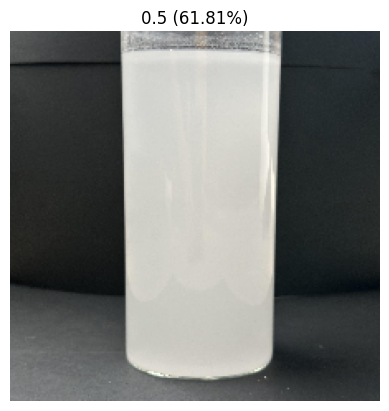

-------
Ảnh: Bản sao của IMG_4189.jpg


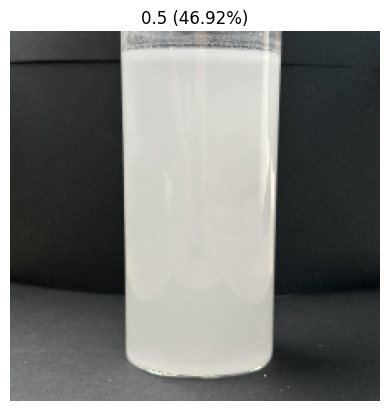

-------
Ảnh: Bản sao của IMG_4164.jpg


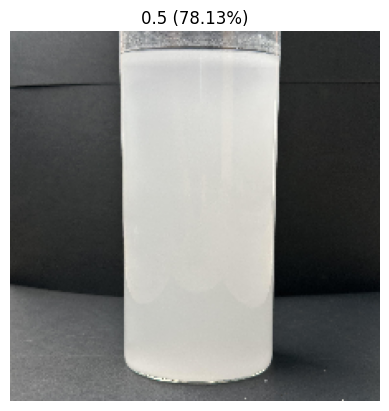

-------
Ảnh: Bản sao của IMG_4181.jpg


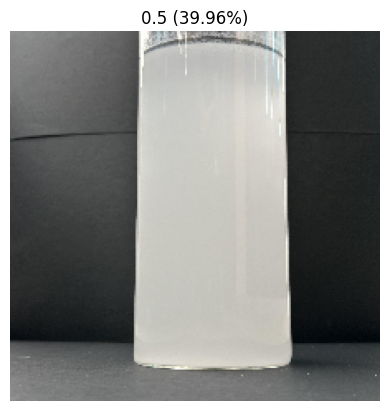

-------
Ảnh: Bản sao của IMG_4180.jpg


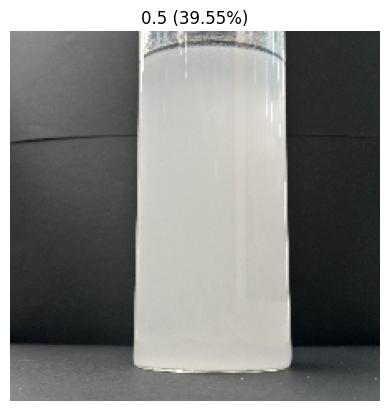

-------


In [ ]:
predict_folder_show("/content/drive/MyDrive/water_0.1 - 0.5_5 class/test/0.5")

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

def evaluate_folder(folder_path):
    correct = 0
    total = 0

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)

        # bỏ qua nếu không phải thư mục
        if not os.path.isdir(class_path):
            continue

        for file in os.listdir(class_path):
            if file.lower().endswith(('.jpg','.png','.jpeg')):
                img_path = os.path.join(class_path, file)

                img = image.load_img(img_path, target_size=(224,224))
                img_array = image.img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)

                prediction = model.predict(img_array, verbose=0)
                pred_class = class_names[np.argmax(prediction)]

                if pred_class == class_name:
                    correct += 1

                total += 1

    wrong = total - correct

    print("Tổng số ảnh test:", total)
    print("Số ảnh dự đoán đúng:", correct)
    print("Số ảnh dự đoán sai:", wrong)
    print("Accuracy:", round(correct/total * 100, 2), "%")
# Test: 40 ảnh
# Đúng: 35 ảnh
# Sai: 5 ảnh

# → Accuracy: 87.5%

In [ ]:
evaluate_folder("/content/drive/MyDrive/water_0.1 - 0.5_5 class/test")

Tổng số ảnh test: 25
Số ảnh dự đoán đúng: 23
Số ảnh dự đoán sai: 2
Accuracy: 92.0 %


In [ ]:
import os

def count_images_per_class(folder_path):
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)

        # chỉ xử lý nếu là thư mục
        if os.path.isdir(class_path):
            count = 0

            for file in os.listdir(class_path):
                if file.lower().endswith(('.jpg','.png','.jpeg')):
                    count += 1

            print(f"{class_name}: {count} ảnh")

In [ ]:
count_images_per_class("/content/drive/MyDrive/rubbish/train")

rac huu co: 268 ảnh
rac vo co: 348 ảnh
rac tai che: 316 ảnh
rac thai nguy hai: 271 ảnh


#CNN

In [ ]:
# CNN-10 MODEL
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# model = Sequential([

#     # ===== Block 1 =====
#     Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(224,224,3)),
#     BatchNormalization(),
#     Conv2D(32, (3,3), padding='same', activation='relu'),
#     MaxPooling2D(2,2),

#     # ===== Block 2 =====
#     Conv2D(64, (3,3), padding='same', activation='relu'),
#     BatchNormalization(),
#     Conv2D(64, (3,3), padding='same', activation='relu'),
#     MaxPooling2D(2,2),

#     # ===== Block 3 =====
#     Conv2D(128, (3,3), padding='same', activation='relu'),
#     BatchNormalization(),
#     Conv2D(128, (3,3), padding='same', activation='relu'),
#     MaxPooling2D(2,2),

#     # ===== Block 4 =====
#     Conv2D(256, (3,3), padding='same', activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D(2,2),

#     # ===== Fully Connected =====
#     Flatten(),
#     Dense(256, activation='relu'),
#     Dropout(0.5),

#     Dense(4, activation='softmax')
# ])

# Tự dừng train khi model không còn học tốt nữa
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# model = Sequential([

#     Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
#     BatchNormalization(),
#     MaxPooling2D(2,2),

#     Conv2D(64, (3,3), activation='relu'),
#     MaxPooling2D(2,2),

#     Conv2D(128, (3,3), activation='relu'),
#     MaxPooling2D(2,2),

#     Flatten(),
#     Dense(128, activation='relu'),
#     Dropout(0.5),

#     Dense(10, activation='softmax')
# ])

# TỐI ƯU
# model = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=(128, 128, 3)),  # sửa ở đây

#     tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
#     tf.keras.layers.MaxPooling2D(),

#     tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
#     tf.keras.layers.MaxPooling2D(),

#     tf.keras.layers.Flatten(),

#     tf.keras.layers.Dense(128, activation='relu'),
#     tf.keras.layers.Dense(10, activation='softmax')
# ])

model = tf.keras.Sequential([

    # Input
    tf.keras.layers.Input(shape=(128, 128, 3)),

    # ===== Block 1 =====
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # ===== Block 2 =====
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # ===== Block 3 =====
    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # ===== Fully Connected =====
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    # Output (4 class rác)
    tf.keras.layers.Dense(4, activation='softmax')
])

#compile, fit

In [ ]:
# Compile (giống)
# model.compile(
#     optimizer='adam',
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train
import tensorflow as tf

# with tf.device('/GPU:0'):
    # history = model.fit(
    #     train_generator,
    #     validation_data=val_generator,
    #     epochs=20,
    #     callbacks=[early_stop]
    # )
# TỐI ƯU
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop]
)
#
# history = model.fit(
#     train_generator,
#     validation_data=val_generator,
#     epochs=20,
#     callbacks=[early_stop]
# )

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 122s 5s/step - accuracy: 0.3400 - loss: 2.3889 - val_accuracy: 0.6800 - val_loss: 1.1375
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 105s 4s/step - accuracy: 0.8325 - loss: 0.6377 - val_accuracy: 1.0000 - val_loss: 0.1377
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.9950 - loss: 0.0597 - val_accuracy: 1.0000 - val_loss: 0.0178
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 104s 4s/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 1.0000 - loss: 8.0546e-04 - val_accuracy: 1.0000 - val_loss: 7.8024e-04
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 1.0000 - loss: 5.1888e-04 - val_accuracy: 1.0000 - val_loss: 5.1002e-04
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 101s 4s/step - accuracy: 1.0000 - loss: 3.6694e-04 - val_

#Dự đoán

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


NameError: name 'train_generator' is not defined

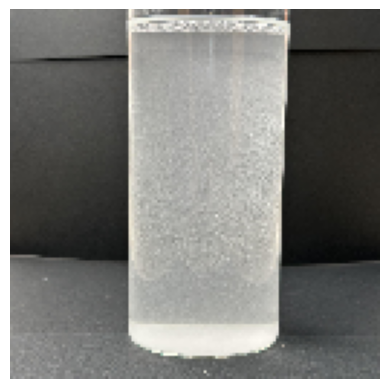

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# import numpy as np
# import matplotlib.pyplot as plt
# from tensorflow.keras.preprocessing import image

# # Hàm dự đoán + hiển thị ảnh
# def predict_image(img_path):
#     img = image.load_img(img_path, target_size=(224,224))

#     # hiển thị ảnh
#     plt.imshow(img)
#     plt.axis("off")

#     # xử lý ảnh
#     img_array = image.img_to_array(img)/255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     # dự đoán
#     prediction = model.predict(img_array)
#     class_names = list(train_generator.class_indices.keys())

#     result = class_names[np.argmax(prediction)]
#     confidence = np.max(prediction)

#     # hiển thị kết quả lên ảnh
#     plt.title(f"{result} ({confidence:.2f})")
#     plt.show()

#     # in kết quả
#     print("Kết quả:", result)
#     print("Độ tin cậy:", confidence)

#     print("Chi tiết từng lớp:")
#     for i, prob in enumerate(prediction[0]):
#         print(class_names[i], ":", round(prob*100,2), "%")

# # Test ảnh từ Google Drive
# predict_image("/content/drive/MyDrive/mẫu/0.1/thang 1/IMG_3761.jpg")

#Dự đoán tối ưu

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


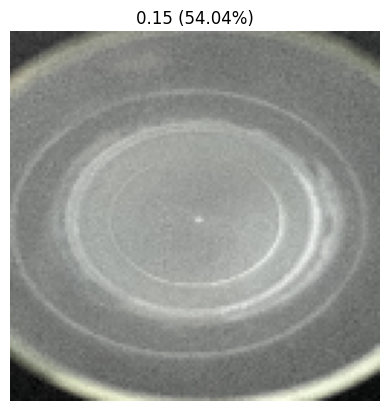

Kết quả: 0.15
Độ tin cậy: 54.04 %
Chi tiết từng lớp:
0.05 : 2.27 %
0.1 : 2.59 %
0.15 : 54.04 %
0.2 : 0.32 %
0.25 : 16.54 %
0.3 : 11.11 %
0.35 : 1.16 %
0.4 : 9.65 %
0.45 : 1.18 %
0.5 : 1.16 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


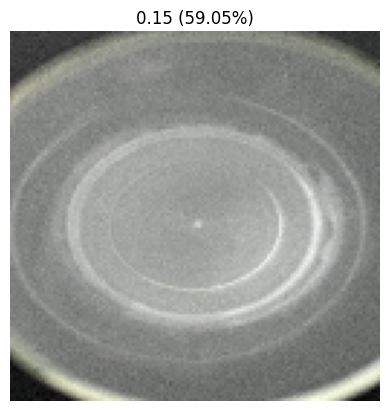

Kết quả: 0.15
Độ tin cậy: 59.05 %
Chi tiết từng lớp:
0.05 : 2.8 %
0.1 : 3.25 %
0.15 : 59.05 %
0.2 : 0.29 %
0.25 : 16.71 %
0.3 : 7.31 %
0.35 : 1.19 %
0.4 : 7.13 %
0.45 : 1.28 %
0.5 : 0.99 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


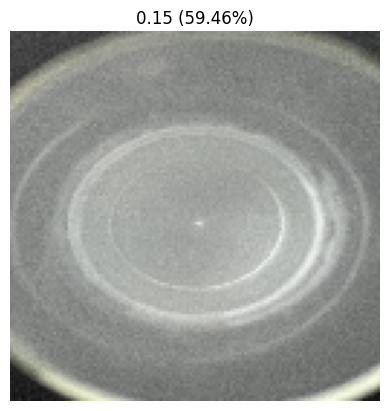

Kết quả: 0.15
Độ tin cậy: 59.46 %
Chi tiết từng lớp:
0.05 : 1.92 %
0.1 : 2.27 %
0.15 : 59.46 %
0.2 : 0.29 %
0.25 : 18.59 %
0.3 : 8.18 %
0.35 : 1.06 %
0.4 : 5.71 %
0.45 : 1.51 %
0.5 : 1.01 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


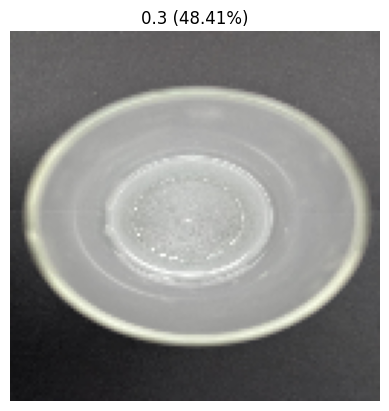

Kết quả: 0.3
Độ tin cậy: 48.41 %
Chi tiết từng lớp:
0.05 : 0.18 %
0.1 : 0.01 %
0.15 : 38.42 %
0.2 : 6.7 %
0.25 : 0.04 %
0.3 : 48.41 %
0.35 : 0.5 %
0.4 : 0.28 %
0.45 : 0.15 %
0.5 : 5.31 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


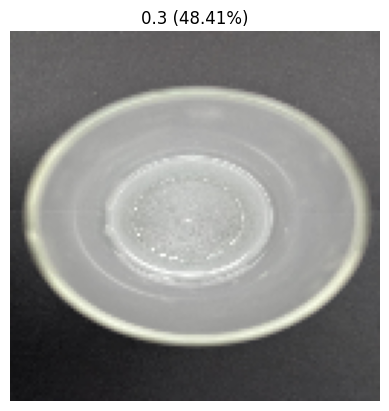

Kết quả: 0.3
Độ tin cậy: 48.41 %
Chi tiết từng lớp:
0.05 : 0.18 %
0.1 : 0.01 %
0.15 : 38.42 %
0.2 : 6.7 %
0.25 : 0.04 %
0.3 : 48.41 %
0.35 : 0.5 %
0.4 : 0.28 %
0.45 : 0.15 %
0.5 : 5.31 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


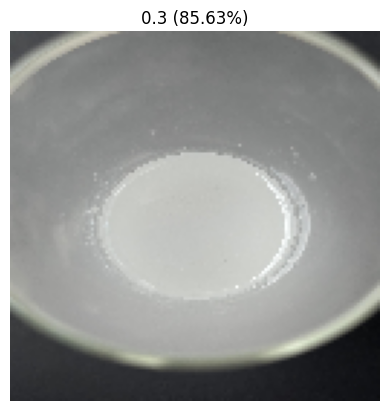

Kết quả: 0.3
Độ tin cậy: 85.63 %
Chi tiết từng lớp:
0.05 : 0.01 %
0.1 : 0.09 %
0.15 : 2.65 %
0.2 : 0.57 %
0.25 : 0.03 %
0.3 : 85.63 %
0.35 : 0.08 %
0.4 : 3.29 %
0.45 : 0.04 %
0.5 : 7.61 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


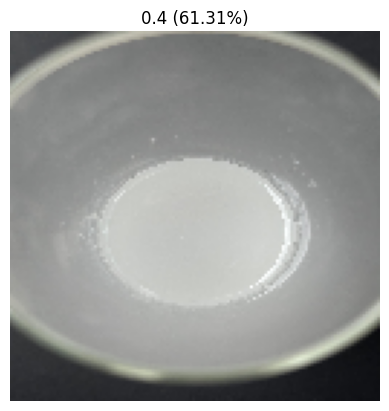

Kết quả: 0.4
Độ tin cậy: 61.31 %
Chi tiết từng lớp:
0.05 : 0.26 %
0.1 : 1.42 %
0.15 : 8.54 %
0.2 : 5.62 %
0.25 : 0.09 %
0.3 : 17.24 %
0.35 : 0.26 %
0.4 : 61.31 %
0.45 : 0.11 %
0.5 : 5.15 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


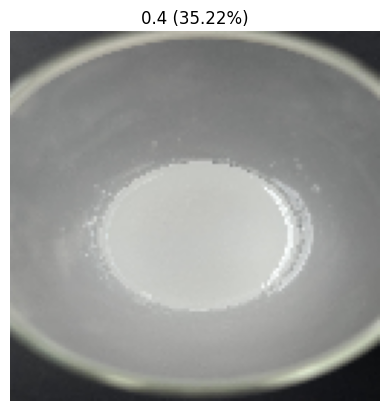

Kết quả: 0.4
Độ tin cậy: 35.22 %
Chi tiết từng lớp:
0.05 : 0.21 %
0.1 : 0.28 %
0.15 : 28.45 %
0.2 : 1.11 %
0.25 : 1.12 %
0.3 : 32.3 %
0.35 : 0.8 %
0.4 : 35.22 %
0.45 : 0.09 %
0.5 : 0.42 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


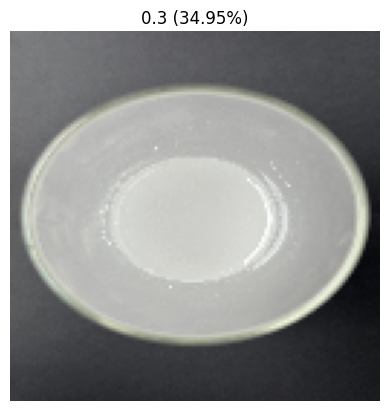

Kết quả: 0.3
Độ tin cậy: 34.95 %
Chi tiết từng lớp:
0.05 : 0.03 %
0.1 : 0.06 %
0.15 : 25.52 %
0.2 : 22.41 %
0.25 : 0.04 %
0.3 : 34.95 %
0.35 : 0.37 %
0.4 : 2.32 %
0.45 : 0.25 %
0.5 : 14.05 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


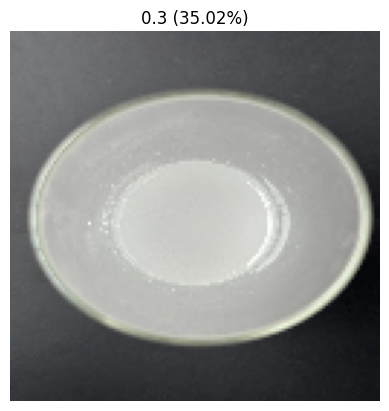

Kết quả: 0.3
Độ tin cậy: 35.02 %
Chi tiết từng lớp:
0.05 : 0.03 %
0.1 : 0.04 %
0.15 : 18.9 %
0.2 : 24.66 %
0.25 : 0.01 %
0.3 : 35.02 %
0.35 : 0.41 %
0.4 : 1.69 %
0.45 : 0.22 %
0.5 : 19.02 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


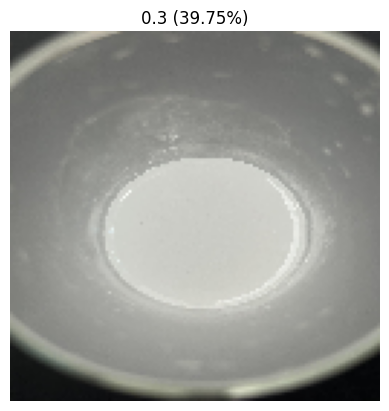

Kết quả: 0.3
Độ tin cậy: 39.75 %
Chi tiết từng lớp:
0.05 : 0.34 %
0.1 : 0.32 %
0.15 : 18.43 %
0.2 : 0.95 %
0.25 : 0.9 %
0.3 : 39.75 %
0.35 : 0.76 %
0.4 : 37.27 %
0.45 : 0.24 %
0.5 : 1.03 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


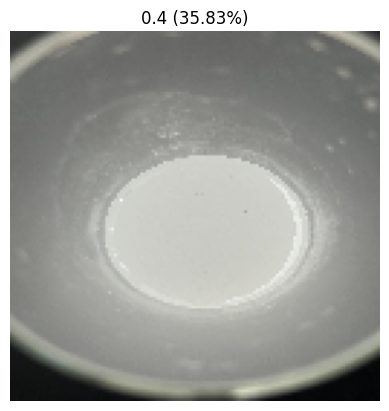

Kết quả: 0.4
Độ tin cậy: 35.83 %
Chi tiết từng lớp:
0.05 : 0.48 %
0.1 : 0.52 %
0.15 : 23.86 %
0.2 : 0.98 %
0.25 : 1.44 %
0.3 : 34.17 %
0.35 : 0.97 %
0.4 : 35.83 %
0.45 : 0.39 %
0.5 : 1.35 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


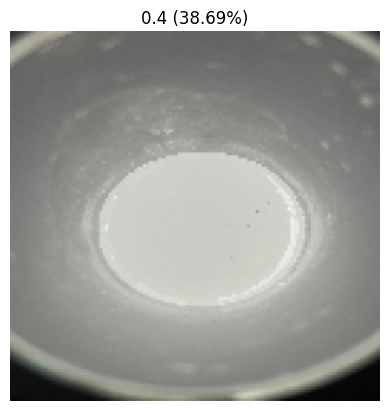

Kết quả: 0.4
Độ tin cậy: 38.69 %
Chi tiết từng lớp:
0.05 : 0.74 %
0.1 : 1.35 %
0.15 : 25.74 %
0.2 : 1.03 %
0.25 : 3.61 %
0.3 : 20.62 %
0.35 : 2.02 %
0.4 : 38.69 %
0.45 : 1.93 %
0.5 : 4.25 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


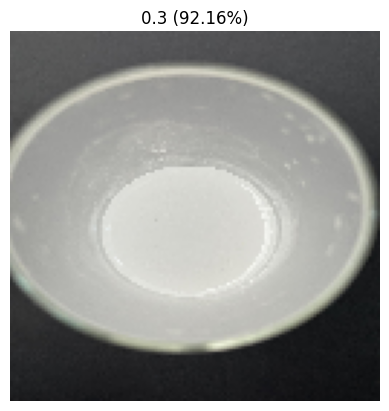

Kết quả: 0.3
Độ tin cậy: 92.16 %
Chi tiết từng lớp:
0.05 : 0.01 %
0.1 : 0.0 %
0.15 : 1.67 %
0.2 : 2.14 %
0.25 : 0.0 %
0.3 : 92.16 %
0.35 : 0.15 %
0.4 : 0.64 %
0.45 : 0.01 %
0.5 : 3.22 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


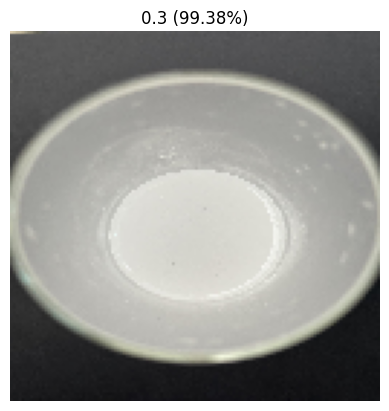

Kết quả: 0.3
Độ tin cậy: 99.38 %
Chi tiết từng lớp:
0.05 : 0.0 %
0.1 : 0.0 %
0.15 : 0.06 %
0.2 : 0.11 %
0.25 : 0.0 %
0.3 : 99.38 %
0.35 : 0.0 %
0.4 : 0.01 %
0.45 : 0.0 %
0.5 : 0.44 %


In [ ]:
# TỐI ƯU
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Hàm dự đoán + hiển thị ảnh
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(128,128))

    plt.imshow(img)
    plt.axis("off")

    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)


    # dùng biến đã lưu
    result = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    plt.title(f"{result} ({confidence*100:.2f}%)")
    plt.show()

    print("Kết quả:", result)
    print("Độ tin cậy:", round(confidence*100,2), "%")

    print("Chi tiết từng lớp:")
    for i, prob in enumerate(prediction[0]):
        print(class_names[i], ":", round(prob*100,2), "%")

# Test ảnh từ Google Drive
predict_image("/content/drive/MyDrive/mẫu (1)/0.05/2x gần/IMG_3608.jpg")

In [ ]:
import os

for folder in ["0.2", "0.05", "0.5", "0.35"]:
    path = f"/content/drive/MyDrive/dataset_nuoc_duc_nhieu/{folder}"
    print(folder, ":", len(os.listdir(path)))

In [ ]:
print(train_generator.class_indices)

NameError: name 'train_generator' is not defined

In [ ]:
print(history.history['accuracy'])
print(history.history['val_accuracy'])